# Predicting Student Dropout & Academic Success
### Machine Learning Project

**Goal:** Predict whether a student will **Dropout**, remain **Enrolled**, or **Graduate**, using only enrollment-time and early-semester data, so the institution can flag at-risk students early enough to intervene.

**In this notebook:**
- ** Load, Data cleaning, EDA, feature engineering, Model, Imbalance **

In [17]:
#Import Libraries
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
sns.set_style("whitegrid")
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression

## Load, Clean & Explore the Data

In [18]:
df_student = pd.read_csv("data.csv", sep = ';')

In [19]:
# Clean column names: strip whitespace, then replace spaces/punctuation
# (parentheses, slashes, apostrophes) with underscores -- e.g. 'Marital status'
# -> 'Marital_status', 'Previous qualification (grade)' -> 'Previous_qualification_grade'.
# .query(), f-strings, or any tool that doesn't like spaces in column names.
df_student.columns = [c.strip() for c in df_student.columns]
df_student.columns = [re.sub(r'[^0-9a-zA-Z]+', '_', c).strip('_') for c in df_student.columns]

print(df_student.shape)
df_student.head()

(4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mother_s_qualification,Father_s_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [9]:
print("Columns:", df_student.columns.tolist())
df_student.info()

Columns: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mother_s_qualification', 'Father_s_qualification', 'Mother_s_occupation', 'Father_s_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Target']
<class 'pandas.DataFrame'>
Ran

In [5]:
# Integrity checks
print("Missing values:", df_student.isna().sum().sum())
print("Duplicate rows:", df_student.duplicated().sum())
print(df_student.dtypes.value_counts())
df_student.describe().T

Missing values: 0
Duplicate rows: 0
int64      29
float64     7
str         1
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother_s_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father_s_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [6]:
print("Missing values per column:")
print(df_student.isna().sum().sort_values(ascending=False))

print("Total duplicates:", df_student.duplicated().sum())

Missing values per column:
Marital_status                                  0
Age_at_enrollment                               0
Curricular_units_1st_sem_credited               0
Curricular_units_1st_sem_enrolled               0
Curricular_units_1st_sem_evaluations            0
Curricular_units_1st_sem_approved               0
Curricular_units_1st_sem_grade                  0
Curricular_units_1st_sem_without_evaluations    0
Curricular_units_2nd_sem_credited               0
Curricular_units_2nd_sem_enrolled               0
Curricular_units_2nd_sem_evaluations            0
Curricular_units_2nd_sem_approved               0
Curricular_units_2nd_sem_grade                  0
Curricular_units_2nd_sem_without_evaluations    0
Unemployment_rate                               0
Inflation_rate                                  0
GDP                                             0
International                                   0
Scholarship_holder                              0
Application_mode       

In [7]:
#Target distribution
target_col = "Target"

print(df_student[target_col].value_counts())
print(df_student[target_col].value_counts(normalize=True).round(3))

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


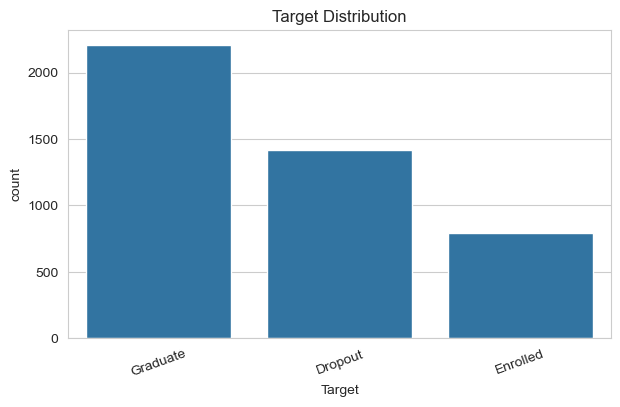

In [8]:
#Visualize Target distribution
plt.figure(figsize=(7,4))
sns.countplot(data=df_student, x=target_col, order=df_student[target_col].value_counts().index)
plt.title("Target Distribution")
plt.xticks(rotation=20)
plt.show()


In [9]:
# Categorical summary
cat_cols = df_student.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    print(f"\n{col}")
    print(df_student[col].value_counts().head())



Target
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_72420/572131043.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_student.select_dtypes(include=["object", "category"]).columns


In [10]:
target_counts = df_student['Target'].value_counts()
print(target_counts)
print(df_student['Target'].value_counts(normalize=True).round(3))


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


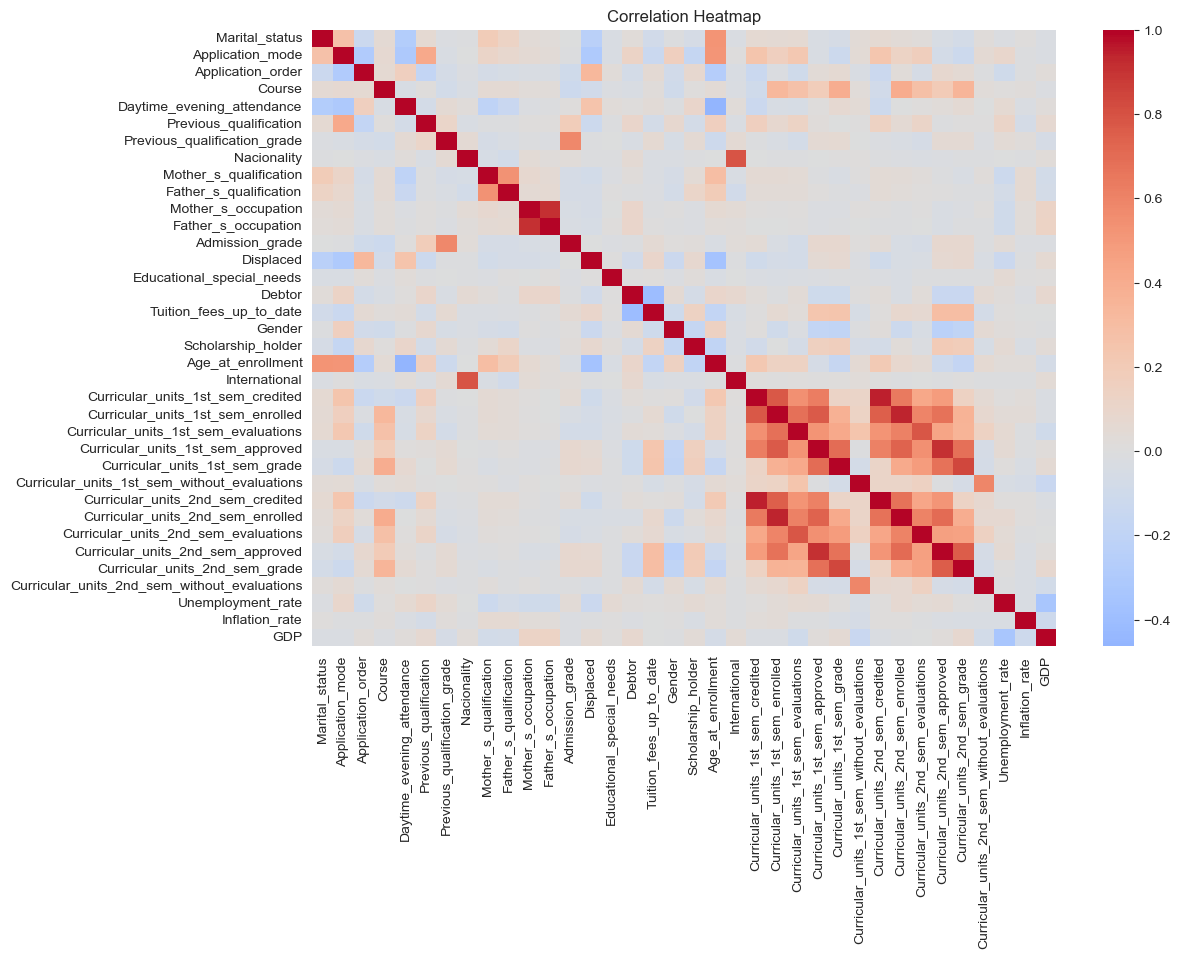

In [11]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(12,8))
sns.heatmap(df_student.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
correlation_matrix_df = df_student.select_dtypes(include=np.number).corr()

In [13]:
correlation_matrix_df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mother_s_qualification,Father_s_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,0.042858,0.070952,-0.000571,0.087654,0.002620,0.065789,0.038695,0.044945,0.048731,0.046592,...,0.059156,0.171429,0.209215,0.182151,0.190762,0.148352,0.049603,0.022659,0.021359,0.015827
std,0.209099,0.239285,0.204390,0.212113,0.213992,0.191558,0.197911,0.212402,0.204148,0.197312,...,0.200268,0.301861,0.317344,0.274776,0.324874,0.292670,0.196910,0.186222,0.171036,0.188070
min,-0.274939,-0.304092,-0.286357,-0.125058,-0.462280,-0.184315,-0.111377,-0.085282,-0.204767,-0.139894,...,-0.144673,-0.125815,-0.124227,-0.061355,-0.224266,-0.199133,-0.080292,-0.335178,-0.112295,-0.335178
25%,-0.029014,-0.032840,-0.090208,-0.028221,-0.043836,-0.011143,-0.037885,-0.018438,-0.041364,-0.038998,...,-0.018418,-0.008215,-0.009089,-0.006353,-0.019551,-0.023337,-0.022859,-0.022474,-0.024174,-0.033408
50%,0.014593,0.046905,-0.029408,0.029849,0.007314,0.015542,-0.011208,-0.007363,0.010979,0.002985,...,0.003035,0.041446,0.047602,0.035004,0.041413,0.051866,-0.005830,0.014141,-0.008018,-0.006223
75%,0.053588,0.161172,0.040564,0.094164,0.040507,0.106044,0.050846,0.011491,0.052662,0.051771,...,0.048738,0.215282,0.402696,0.428628,0.447583,0.309542,0.055748,0.046800,0.017960,0.037835
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df_student['Marital_status'].unique()

array([1, 2, 4, 3, 5, 6])

In [15]:
crosstab_df = pd.crosstab(df_student['Marital_status'], df_student['Target'])
crosstab_df

Target,Dropout,Enrolled,Graduate
Marital_status,,,
1,1184,720,2015
2,179,52,148
3,1,2,1
4,42,16,33
5,11,3,11
6,4,1,1


In [16]:
from scipy.stats import chi2_contingency

In [17]:
chi2_contingency(crosstab_df)

Chi2ContingencyResult(statistic=np.float64(63.43854947026341), pvalue=np.float64(8.05427970388931e-10), dof=10, expected_freq=array([[1.25879272e+03, 7.03364828e+02, 1.95684245e+03],
       [1.21735759e+02, 6.80212477e+01, 1.89242993e+02],
       [1.28481013e+00, 7.17902351e-01, 1.99728752e+00],
       [2.92294304e+01, 1.63322785e+01, 4.54382911e+01],
       [8.03006329e+00, 4.48688969e+00, 1.24830470e+01],
       [1.92721519e+00, 1.07685353e+00, 2.99593128e+00]]))

In [18]:
df_student.groupby('Target')['Previous_qualification_grade'].mean()

Target
Dropout     131.114075
Enrolled    131.208438
Graduate    134.082707
Name: Previous_qualification_grade, dtype: float64

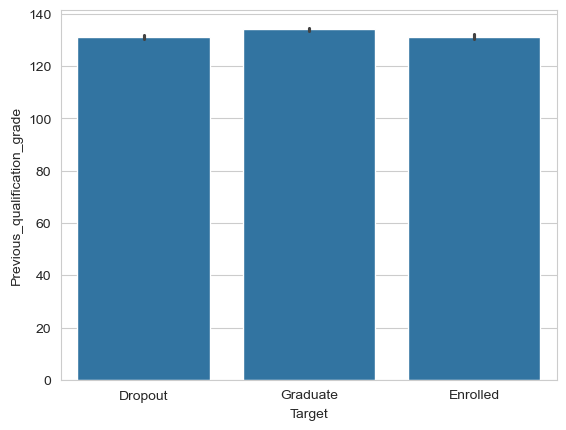

In [10]:
sns.barplot(data=df_student, x='Target', y='Previous_qualification_grade');

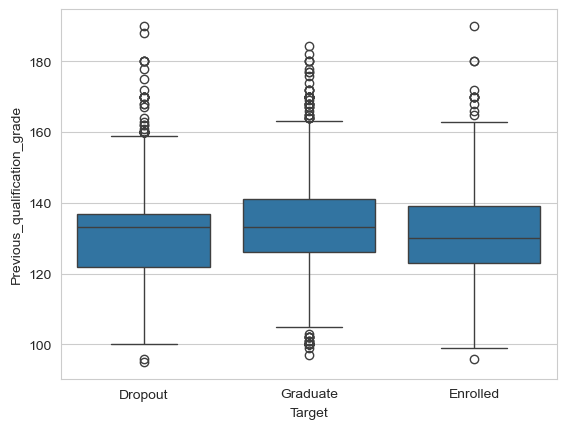

In [11]:
sns.boxplot(data=df_student, x='Target', y='Previous_qualification_grade');

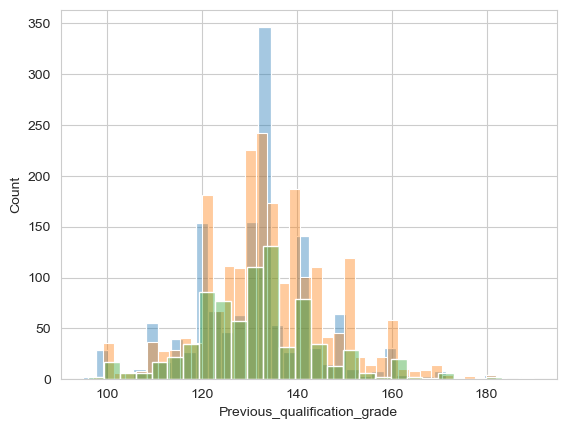

In [12]:
fig, axes = plt.subplots()
sns.histplot(data=df_student[df_student['Target'] == "Dropout"], x='Previous_qualification_grade', alpha=0.4, ax=axes);
sns.histplot(data=df_student[df_student['Target'] == "Graduate"], x='Previous_qualification_grade', alpha=0.4, ax=axes);
sns.histplot(data=df_student[df_student['Target'] == "Enrolled"], x='Previous_qualification_grade', alpha=0.4, ax=axes);
plt.show()

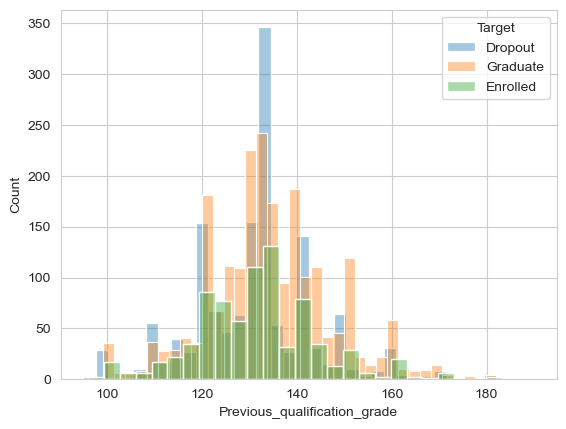

In [15]:
fig, axes = plt.subplots()

sns.histplot(
    data=df_student[df_student['Target'] == "Dropout"],
    x='Previous_qualification_grade',
    alpha=0.4,
    label='Dropout',
    ax=axes
)

sns.histplot(
    data=df_student[df_student['Target'] == "Graduate"],
    x='Previous_qualification_grade',
    alpha=0.4,
    label='Graduate',
    ax=axes
)

sns.histplot(
    data=df_student[df_student['Target'] == "Enrolled"],
    x='Previous_qualification_grade',
    alpha=0.4,
    label='Enrolled',
    ax=axes
)

axes.legend(title='Target')

# Feature Engineering Plan : Identify which feature have a stronger relation with " Target " 
**Target column = Categorical**
**Categorical vs categorical -> Chi2**
**Numerical vs Categorical -> groupby**

# Feature Relationship with Target

The target variable contains three categories:

- Dropout
- Enrolled
- Graduate

For this analysis:

- Categorical feature vs categorical target: Chi-square test
- Numerical feature vs categorical target: Groupby summary and boxplot

## Selected Features

Most of these variables are stored as numbers, but their numbers are category codes.

In [26]:
# Define the target column
target_col = "Target"

# Features recommended by your teacher
selected_features = [
    "Marital_status",
    "Application_mode",
    "Application_order",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Previous_qualification_grade",
    "Nacionality",
    "Mother_s_qualification",
    "Father_s_qualification",
    "Mother_s_occupation",
    "Father_s_occupation"
]

# Check that all required columns exist
missing_columns = [
    column for column in selected_features + [target_col]
    if column not in df_student.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


## Data Validation

Before performing statistical tests, check:

1. The number of rows and columns.
2. Missing values.
3. Duplicate rows.
4. Data types.
5. The values in the target column.


In [27]:
# Create a smaller dataframe containing only the required columns
analysis_df = df_student[selected_features + [target_col]].copy()

# Dataset size
print("Rows and columns:", analysis_df.shape)

Rows and columns: (4424, 13)


In [28]:
# Check missing values
analysis_df.isna().sum()

Marital_status                  0
Application_mode                0
Application_order               0
Course                          0
Daytime_evening_attendance      0
Previous_qualification          0
Previous_qualification_grade    0
Nacionality                     0
Mother_s_qualification          0
Father_s_qualification          0
Mother_s_occupation             0
Father_s_occupation             0
Target                          0
dtype: int64

In [29]:
# Check duplicate rows
print("Number of duplicate rows:", analysis_df.duplicated().sum())

Number of duplicate rows: 24


# Investigating Duplicate Rows

First, we will display all rows that belong to a duplicate group.

We use `keep=False` so that both the first row and its repeated rows are shown.

In [30]:
print(
    "Rows belonging to duplicate groups:",
    analysis_df.duplicated(keep=False).sum()
)

Rows belonging to duplicate groups: 42


## Checking the Complete Dataset

We will now check for duplicates using all columns in the original dataset.

This gives us a better indication of whether the records are exact duplicates.

In [31]:
# Check exact duplicate rows using all columns in the original dataframe

print(
    "Duplicate rows in the complete dataset:",
    analysis_df.duplicated().sum()
)

Duplicate rows in the complete dataset: 24


In [32]:
full_duplicate_rows = analysis_df[
    analysis_df.duplicated(keep=False)
]

full_duplicate_rows.head(20)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mother_s_qualification,Father_s_qualification,Mother_s_occupation,Father_s_occupation,Target
44,1,39,1,9991,0,1,133.1,1,37,37,9,9,Dropout
213,1,39,1,9991,0,1,133.1,1,37,37,9,9,Dropout
247,1,44,1,9003,1,39,130.0,1,37,37,9,10,Dropout
727,1,39,1,9991,0,1,133.1,1,37,37,9,9,Dropout
914,1,39,1,9500,1,1,140.0,1,37,37,9,6,Dropout
921,1,39,1,8014,0,1,133.1,1,37,37,9,9,Graduate
951,2,39,1,9991,0,1,133.1,1,37,37,9,9,Dropout
960,1,39,1,9670,1,1,120.0,1,34,34,0,0,Dropout
1240,1,43,1,9991,0,1,120.0,1,37,37,9,9,Dropout
1291,1,1,1,9500,1,1,143.0,1,38,38,9,9,Graduate


In [33]:
row_247 = analysis_df.iloc[247]
row_727 = analysis_df.iloc[727]

comparison = pd.DataFrame({
    "Row_247": row_247,
    "Row_727": row_727
})

comparison["Same_value"] = (
    comparison["Row_247"] == comparison["Row_727"]
)

comparison

,Row_247,Row_727,Same_value
Marital_status,1,1,True
Application_mode,44,39,False
Application_order,1,1,True
Course,9003,9991,False
Daytime_evening_attendance,1,0,False
Previous_qualification,39,1,False
Previous_qualification_grade,130.0,133.1,False
Nacionality,1,1,True
Mother_s_qualification,37,37,True
Father_s_qualification,37,37,True


In [34]:
# Check whether the two complete rows are exactly equal

are_exactly_equal = analysis_df.loc[247].equals(
    analysis_df.loc[727]
)

print("Are the rows exactly equal?", are_exactly_equal)

Are the rows exactly equal? False


In [35]:
# Count values that are the same
same_values = comparison["Same_value"].sum()

# Count values that are different
different_values = (
    comparison["Same_value"] == False
).sum()

print("Same values:", same_values)
print("Different values:", different_values)

Same values: 7
Different values: 6


In [36]:
duplicate_rows = analysis_df[
    analysis_df.duplicated(keep=False)
].sort_values(
    by=selected_features + [target_col]
)

duplicate_rows

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mother_s_qualification,Father_s_qualification,Mother_s_occupation,Father_s_occupation,Target
2462,1,1,1,171,1,1,159.0,1,3,3,2,2,Dropout
4033,1,1,1,171,1,1,159.0,1,3,3,2,2,Dropout
1875,1,1,1,9500,1,1,125.0,1,37,37,9,9,Graduate
2735,1,1,1,9500,1,1,125.0,1,37,37,9,9,Graduate
1291,1,1,1,9500,1,1,143.0,1,38,38,9,9,Graduate
2571,1,1,1,9500,1,1,143.0,1,38,38,9,9,Graduate
2084,1,1,1,9773,1,1,127.0,1,19,37,9,9,Graduate
2293,1,1,1,9773,1,1,127.0,1,19,37,9,9,Graduate
1544,1,39,1,8014,0,1,133.1,1,34,34,0,0,Dropout
1873,1,39,1,8014,0,1,133.1,1,34,34,0,0,Dropout


In [37]:
# Get the indexes of duplicate rows in analysis_df

duplicate_indexes = duplicate_rows.index

# Display those records using all original columns

analysis_df.loc[duplicate_indexes]

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mother_s_qualification,Father_s_qualification,Mother_s_occupation,Father_s_occupation,Target
2462,1,1,1,171,1,1,159.0,1,3,3,2,2,Dropout
4033,1,1,1,171,1,1,159.0,1,3,3,2,2,Dropout
1875,1,1,1,9500,1,1,125.0,1,37,37,9,9,Graduate
2735,1,1,1,9500,1,1,125.0,1,37,37,9,9,Graduate
1291,1,1,1,9500,1,1,143.0,1,38,38,9,9,Graduate
2571,1,1,1,9500,1,1,143.0,1,38,38,9,9,Graduate
2084,1,1,1,9773,1,1,127.0,1,19,37,9,9,Graduate
2293,1,1,1,9773,1,1,127.0,1,19,37,9,9,Graduate
1544,1,39,1,8014,0,1,133.1,1,34,34,0,0,Dropout
1873,1,39,1,8014,0,1,133.1,1,34,34,0,0,Dropout


### Duplicate Row Decision

Rows 247 and 727 were compared because they shared several feature values. However, six feature values were different, including application mode, course, attendance type, previous qualification, previous qualification grade, and father's occupation.

Therefore, the rows were not exact duplicates and were retained.

The dataset contained no exact duplicate records when all original columns were considered. Repeated values in individual columns are expected because different students can have similar demographic, application, and academic characteristics.

In [38]:
# Check data types
analysis_df.dtypes

Marital_status                    int64
Application_mode                  int64
Application_order                 int64
Course                            int64
Daytime_evening_attendance        int64
Previous_qualification            int64
Previous_qualification_grade    float64
Nacionality                       int64
Mother_s_qualification            int64
Father_s_qualification            int64
Mother_s_occupation               int64
Father_s_occupation               int64
Target                              str
dtype: object

In [39]:
# Check target categories
print(analysis_df[target_col].value_counts())

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [40]:
# Check target proportions
target_percentage = (
    analysis_df[target_col]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_percentage

Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

## Chi-Square Test

The chi-square test checks whether two categorical variables are statistically associated.

In [41]:
categorical_features = [
    "Marital_status",
    "Application_mode",
    "Application_order",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Nacionality",
    "Mother_s_qualification",
    "Father_s_qualification",
    "Mother_s_occupation",
    "Father_s_occupation"
]

numerical_features = [
    "Previous_qualification_grade"
]


In [42]:
# Marital status versus Target

contingency_table = pd.crosstab(
    analysis_df["Marital_status"],
    analysis_df[target_col]
)

contingency_table

Target,Dropout,Enrolled,Graduate
Marital_status,,,
1,1184,720,2015
2,179,52,148
3,1,2,1
4,42,16,33
5,11,3,11
6,4,1,1


In [43]:
# Perform the chi-square test

chi2_statistic, p_value, degrees_of_freedom, expected_values = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", round(chi2_statistic, 3))
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 63.439
p-value: 8.05427970388931e-10
Degrees of freedom: 10


In [44]:
# Interpret the result

if p_value < 0.05:
    print("Result: There is evidence of an association with Target.")
else:
    print("Result: There is not enough evidence of an association with Target.")


Result: There is evidence of an association with Target.


In [45]:
# Course versus Target

contingency_table2 = pd.crosstab(
    analysis_df["Course"],
    analysis_df[target_col]
)

contingency_table2

Target,Dropout,Enrolled,Graduate
Course,,,
33,8,3,1
171,82,37,96
8014,71,21,123
9003,86,37,87
9070,51,42,133
9085,90,75,172
9119,92,64,14
9130,78,21,42
9147,134,108,138


In [46]:
# Perform the chi-square test

chi2_statistic, p_value, degrees_of_freedom, expected_values = chi2_contingency(
    contingency_table2
)

print("Chi-square statistic:", round(chi2_statistic, 3))
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 558.284
p-value: 2.3165709040666173e-97
Degrees of freedom: 32


In [47]:
# Application Order status versus Target

contingency_table3 = pd.crosstab(
    analysis_df["Application_order"],
    analysis_df[target_col]
)

contingency_table3

Target,Dropout,Enrolled,Graduate
Application_order,,,
0,0,0,1
1,1053,565,1408
2,150,96,301
3,76,60,173
4,58,31,160
5,53,25,76
6,31,16,90
9,0,1,0


In [44]:
# Perform the chi-square test

chi2_statistic, p_value, degrees_of_freedom, expected_values = chi2_contingency(
    contingency_table3
)

print("Chi-square statistic:", round(chi2_statistic, 3))
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 69.609
p-value: 2.2720348303712394e-09
Degrees of freedom: 14


In [45]:
# Daytime evening attendance status versus Target

contingency_table4 = pd.crosstab(
    analysis_df["Daytime_evening_attendance"],
    analysis_df[target_col]
)

contingency_table4

Target,Dropout,Enrolled,Graduate
Daytime_evening_attendance,,,
0,207,75,201
1,1214,719,2008


In [46]:
# Perform the chi-square test

chi2_statistic, p_value, degrees_of_freedom, expected_values = chi2_contingency(
    contingency_table4
)

print("Chi-square statistic:", round(chi2_statistic, 3))
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 28.74
p-value: 5.743834299642735e-07
Degrees of freedom: 2


In [47]:
# Application mode status versus Target

contingency_table5 = pd.crosstab(
    analysis_df["Application_mode"],
    analysis_df[target_col]
)

contingency_table5

Target,Dropout,Enrolled,Graduate
Application_mode,,,
1,345,300,1063
2,2,0,1
5,2,8,6
7,85,7,47
10,3,0,7
15,5,10,15
16,5,8,25
17,256,159,457
18,45,16,63


In [48]:
# Perform the chi-square test

chi2_statistic, p_value, degrees_of_freedom, expected_values = chi2_contingency(
    contingency_table5
)

print("Chi-square statistic:", round(chi2_statistic, 3))
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 466.514
p-value: 1.964656781464711e-77
Degrees of freedom: 34


## Chi-Square Results for All Categorical Features

In [48]:
chi_square_results = []

for feature in categorical_features:
    
    # Creating frequency table
    contingency_table = pd.crosstab(
        analysis_df[feature],
        analysis_df[target_col]
    )
    
    # Perform the chi-square test
    chi2_statistic, p_value, degrees_of_freedom, expected_values = chi2_contingency(
        contingency_table
    )
    
    # Check how many expected frequencies are below 5
    small_expected_values = (expected_values < 5).sum()
    
    # Store the results
    chi_square_results.append({
        "Feature": feature,
        "Chi-square statistic": chi2_statistic,
        "p-value": p_value,
        "Degrees of freedom": degrees_of_freedom,
        "Expected cells below 5": small_expected_values
    })

chi_square_results_df = pd.DataFrame(chi_square_results)

chi_square_results_df


,Feature,Chi-square statistic,p-value,Degrees of freedom,Expected cells below 5
0,Marital_status,63.438549,8.054280e-10,10,7
1,Application_mode,466.513683,1.964657e-77,34,16
2,Application_order,69.608664,2.272035e-09,14,6
3,Course,558.284474,2.316571e-97,32,2
4,Daytime_evening_attendance,28.739937,5.743834e-07,2,0
5,Previous_qualification,219.680709,7.160305e-30,32,25
6,Nacionality,45.857525,2.422255e-01,40,54
7,Mother_s_qualification,217.952131,5.823844e-21,56,58
8,Father_s_qualification,225.000783,3.175007e-19,66,71
9,Mother_s_occupation,291.921705,1.630859e-31,62,58


In [50]:
# Round the numerical columns to make the table easier to read

chi_square_results_df = chi_square_results_df.round({
    "Chi-square statistic": 3,
    "p-value": 5
})

chi_square_results_df

,Feature,Chi-square statistic,p-value,Degrees of freedom,Expected cells below 5
0,Marital_status,63.439,0.00000,10,7
1,Application_mode,466.514,0.00000,34,16
2,Application_order,69.609,0.00000,14,6
3,Course,558.284,0.00000,32,2
4,Daytime_evening_attendance,28.740,0.00000,2,0
5,Previous_qualification,219.681,0.00000,32,25
6,Nacionality,45.858,0.24223,40,54
7,Mother_s_qualification,217.952,0.00000,56,58
8,Father_s_qualification,225.001,0.00000,66,71
9,Mother_s_occupation,291.922,0.00000,62,58


In [51]:
# Add a simple interpretation column

chi_square_results_df["Interpretation"] = np.where(
    chi_square_results_df["p-value"] < 0.05,
    "Significant association",
    "No significant association"
)

chi_square_results_df.sort_values("p-value")


,Feature,Chi-square statistic,p-value,Degrees of freedom,Expected cells below 5,Interpretation
0,Marital_status,63.439,0.00000,10,7,Significant association
1,Application_mode,466.514,0.00000,34,16,Significant association
2,Application_order,69.609,0.00000,14,6,Significant association
3,Course,558.284,0.00000,32,2,Significant association
4,Daytime_evening_attendance,28.740,0.00000,2,0,Significant association
5,Previous_qualification,219.681,0.00000,32,25,Significant association
7,Mother_s_qualification,217.952,0.00000,56,58,Significant association
8,Father_s_qualification,225.001,0.00000,66,71,Significant association
9,Mother_s_occupation,291.922,0.00000,62,58,Significant association
10,Father_s_occupation,264.500,0.00000,90,99,Significant association


In [52]:
# Target percentage within each Marital status category

marital_target_percentages = pd.crosstab(
    analysis_df["Marital_status"],
    analysis_df[target_col],
    normalize="index"
).mul(100).round(2)

marital_target_percentages


Target,Dropout,Enrolled,Graduate
Marital_status,,,
1,30.21,18.37,51.42
2,47.23,13.72,39.05
3,25.00,50.00,25.00
4,46.15,17.58,36.26
5,44.00,12.00,44.00
6,66.67,16.67,16.67


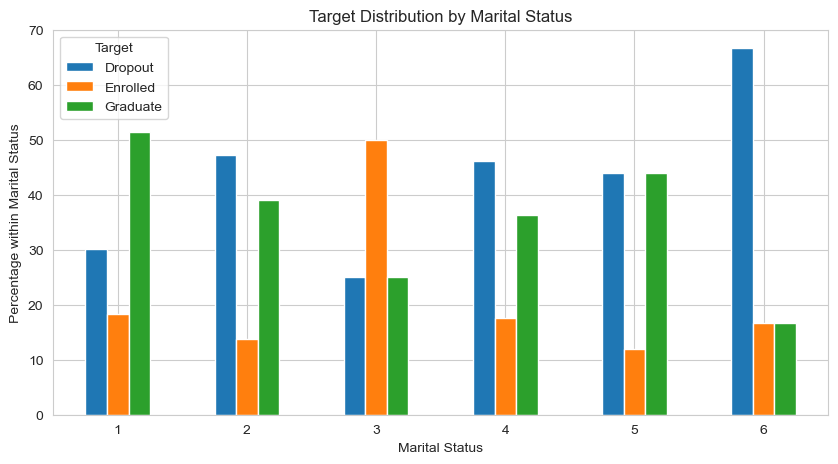

In [53]:
# Plot the percentage of each Target category by Marital status

marital_target_percentages.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Target Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Percentage within Marital Status")
plt.legend(title="Target")
plt.xticks(rotation=0)
plt.show()

In [54]:
# Target percentage within each Aplication Mode category

Application_mode_target_percentages = pd.crosstab(
    analysis_df["Application_mode"],
    analysis_df[target_col],
    normalize="index"
).mul(100).round(2)

Application_mode_target_percentages

Target,Dropout,Enrolled,Graduate
Application_mode,,,
1,20.20,17.56,62.24
2,66.67,0.00,33.33
5,12.50,50.00,37.50
7,61.15,5.04,33.81
10,30.00,0.00,70.00
15,16.67,33.33,50.00
16,13.16,21.05,65.79
17,29.36,18.23,52.41
18,36.29,12.90,50.81


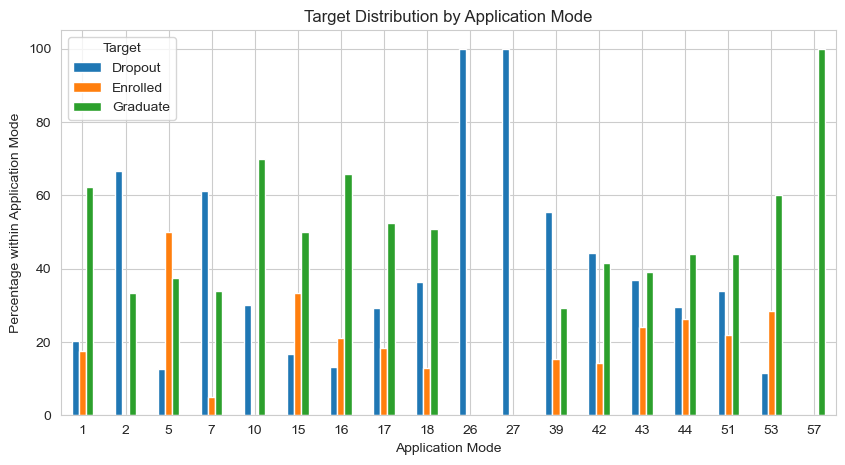

In [55]:
# Plot the percentage of each Target category by Application Mode

Application_mode_target_percentages.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Target Distribution by Application Mode")
plt.xlabel("Application Mode")
plt.ylabel("Percentage within Application Mode")
plt.legend(title="Target")
plt.xticks(rotation=0)
plt.show()

feature = "Application mode"

percentage_table = pd.crosstab(
    analysis_df[feature],
    analysis_df[target_col],
    normalize="index"
).mul(100)

percentage_table.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title(f"Target Distribution by {feature}")
plt.xlabel(feature)
plt.ylabel("Percentage")
plt.legend(title="Target")
plt.show()


In [56]:
# Target percentage within each Course category

Course_target_percentages = pd.crosstab(
    analysis_df["Course"],
    analysis_df[target_col],
    normalize="index"
).mul(100).round(2)

Course_target_percentages

Target,Dropout,Enrolled,Graduate
Course,,,
33,66.67,25.00,8.33
171,38.14,17.21,44.65
8014,33.02,9.77,57.21
9003,40.95,17.62,41.43
9070,22.57,18.58,58.85
9085,26.71,22.26,51.04
9119,54.12,37.65,8.24
9130,55.32,14.89,29.79
9147,35.26,28.42,36.32


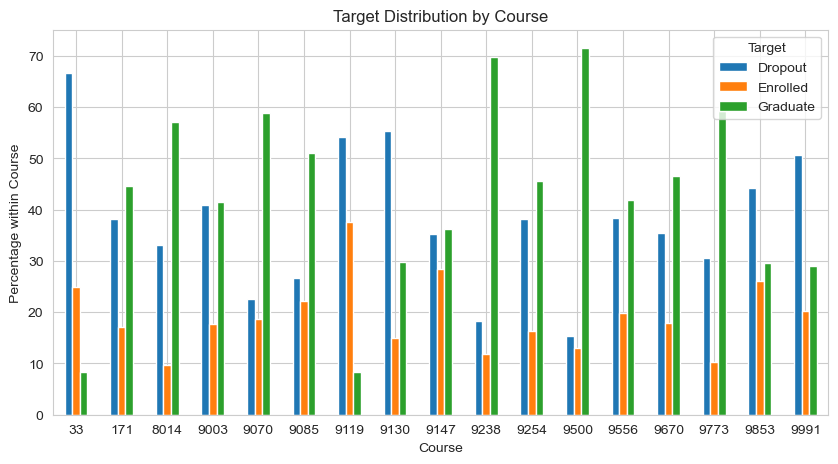

In [57]:
# Plot the percentage of each Target category by Course

Course_target_percentages.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Target Distribution by Course")
plt.xlabel("Course")
plt.ylabel("Percentage within Course")
plt.legend(title="Target")
plt.xticks(rotation=0)
plt.show()

In [58]:
# Target percentage within each daytime evening attendance category

Daytime_evening_attendance_target_percentages = pd.crosstab(
    analysis_df["Daytime_evening_attendance"],
    analysis_df[target_col],
    normalize="index"
).mul(100).round(2)

Daytime_evening_attendance_target_percentages

Target,Dropout,Enrolled,Graduate
Daytime_evening_attendance,,,
0,42.86,15.53,41.61
1,30.80,18.24,50.95


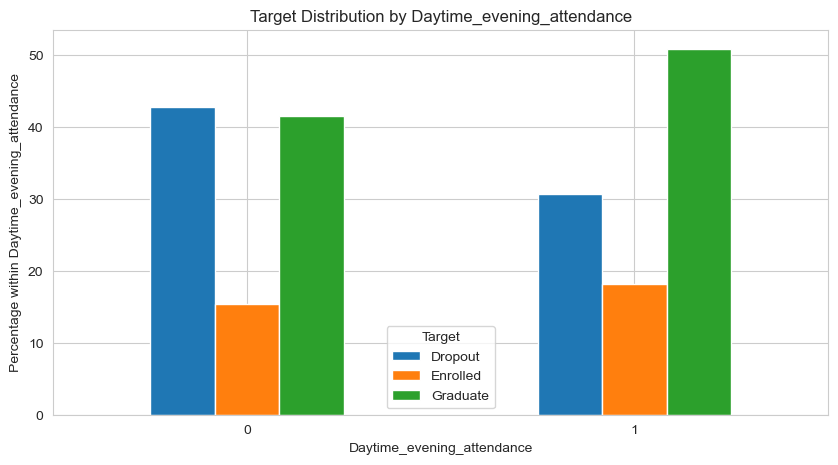

In [59]:
# Plot the percentage of each Target category by daytime evening attendance

Daytime_evening_attendance_target_percentages.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Target Distribution by Daytime_evening_attendance")
plt.xlabel("Daytime_evening_attendance")
plt.ylabel("Percentage within Daytime_evening_attendance")
plt.legend(title="Target")
plt.xticks(rotation=0)
plt.show()

## Numerical Feature versus Target

`Previous qualification (grade)` is numerical.

Because `Target` is categorical, calculate summary statistics for the grade within each target group.

Comparing:

- Number of students
- Mean grade
- Median grade
- Standard deviation
- Minimum grade
- Maximum grade

In [60]:
grade_column = "Previous_qualification_grade"

grade_summary = (
    analysis_df
    .groupby(target_col)[grade_column]
    .agg(
        Number_of_students="count",
        Mean="mean",
        Median="median",
        Standard_deviation="std",
        Minimum="min",
        Maximum="max"
    )
    .round(2)
)

grade_summary

,Number_of_students,Mean,Median,Standard_deviation,Minimum,Maximum
Target,,,,,,
Dropout,1421,131.11,133.1,12.87,95.0,190.0
Enrolled,794,131.21,130.0,12.87,96.0,190.0
Graduate,2209,134.08,133.1,13.34,97.0,184.4


In [61]:
analysis_df.groupby(target_col)[grade_column].mean().round(2)

Target
Dropout     131.11
Enrolled    131.21
Graduate    134.08
Name: Previous_qualification_grade, dtype: float64

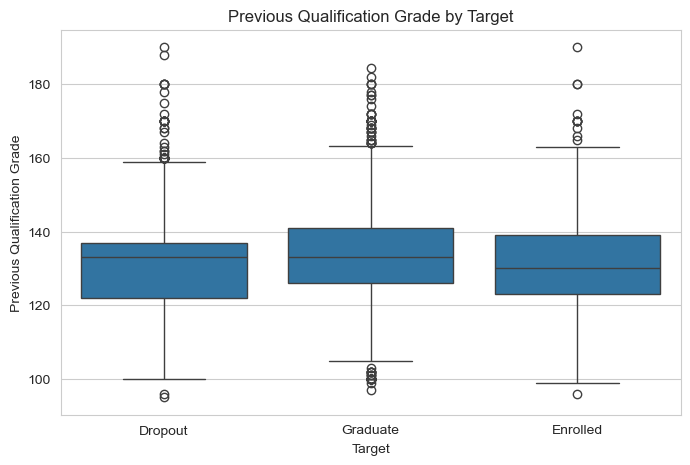

In [62]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_df,
    x=target_col,
    y=grade_column
)

plt.title("Previous Qualification Grade by Target")
plt.xlabel("Target")
plt.ylabel("Previous Qualification Grade")
plt.show()

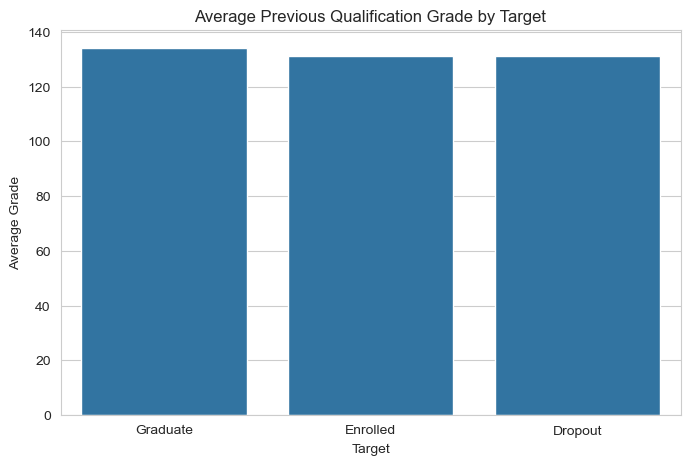

In [63]:
mean_grade = (
    analysis_df
    .groupby(target_col)[grade_column]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=mean_grade.index,
    y=mean_grade.values
)

plt.title("Average Previous Qualification Grade by Target")
plt.xlabel("Target")
plt.ylabel("Average Grade")
plt.show()

## Feature Selection Summary

For categorical variables, use the chi-square p-value as an initial screening tool.

For the numerical variable, compare the group means, medians, and boxplots.


In [64]:
# Display categorical features with significant results first

chi_square_results_df.sort_values(
    by="p-value",
    ascending=True
)

,Feature,Chi-square statistic,p-value,Degrees of freedom,Expected cells below 5,Interpretation
0,Marital_status,63.439,0.00000,10,7,Significant association
1,Application_mode,466.514,0.00000,34,16,Significant association
2,Application_order,69.609,0.00000,14,6,Significant association
3,Course,558.284,0.00000,32,2,Significant association
4,Daytime_evening_attendance,28.740,0.00000,2,0,Significant association
5,Previous_qualification,219.681,0.00000,32,25,Significant association
7,Mother_s_qualification,217.952,0.00000,56,58,Significant association
8,Father_s_qualification,225.001,0.00000,66,71,Significant association
9,Mother_s_occupation,291.922,0.00000,62,58,Significant association
10,Father_s_occupation,264.500,0.00000,90,99,Significant association


In [65]:
# Calculate Cramer's V for every categorical feature

cramers_results = []

for feature in categorical_features:
    
    # Create a contingency table
    contingency_table = pd.crosstab(
        analysis_df[feature],
        analysis_df[target_col]
    )
    
    # Perform the chi-square test
    chi2_statistic, p_value, degrees_of_freedom, expected_values = (
        chi2_contingency(contingency_table)
    )
    
    # Calculate the percentage of expected cells below 5
    total_cells = expected_values.size
    cells_below_5 = (expected_values < 5).sum()
    percentage_below_5 = (cells_below_5 / total_cells) * 100
    
    # Calculate Cramer's V
    number_of_rows = contingency_table.shape[0]
    number_of_columns = contingency_table.shape[1]
    sample_size = contingency_table.to_numpy().sum()
    
    denominator = min(
        number_of_rows - 1,
        number_of_columns - 1
    )
    
    cramers_v = np.sqrt(
        (chi2_statistic / sample_size) / denominator
    )
    
    cramers_results.append({
        "Feature": feature,
        "Chi-square statistic": chi2_statistic,
        "p-value": p_value,
        "Cramer's V": cramers_v,
        "Expected cells below 5": cells_below_5,
        "Percentage below 5": percentage_below_5
    })

cramers_results_df = pd.DataFrame(cramers_results)

cramers_results_df = cramers_results_df.sort_values(
    by="Cramer's V",
    ascending=False
)

cramers_results_df.round(4)

,Feature,Chi-square statistic,p-value,Cramer's V,Expected cells below 5,Percentage below 5
3,Course,558.2845,0.0000,0.2512,2,3.9216
1,Application_mode,466.5137,0.0000,0.2296,16,29.6296
9,Mother_s_occupation,291.9217,0.0000,0.1816,58,60.4167
10,Father_s_occupation,264.4998,0.0000,0.1729,99,71.7391
8,Father_s_qualification,225.0008,0.0000,0.1595,71,69.6078
5,Previous_qualification,219.6807,0.0000,0.1576,25,49.0196
7,Mother_s_qualification,217.9521,0.0000,0.1569,58,66.6667
2,Application_order,69.6087,0.0000,0.0887,6,25.0000
0,Marital_status,63.4385,0.0000,0.0847,7,38.8889
4,Daytime_evening_attendance,28.7399,0.0000,0.0806,0,0.0000


In [66]:
feature_selection_summary = chi_square_results_df[
    [
        "Feature",
        "Chi-square statistic",
        "p-value",
        "Interpretation"
    ]
].copy()

feature_selection_summary

,Feature,Chi-square statistic,p-value,Interpretation
0,Marital_status,63.439,0.00000,Significant association
1,Application_mode,466.514,0.00000,Significant association
2,Application_order,69.609,0.00000,Significant association
3,Course,558.284,0.00000,Significant association
4,Daytime_evening_attendance,28.740,0.00000,Significant association
5,Previous_qualification,219.681,0.00000,Significant association
6,Nacionality,45.858,0.24223,No significant association
7,Mother_s_qualification,217.952,0.00000,Significant association
8,Father_s_qualification,225.001,0.00000,Significant association
9,Mother_s_occupation,291.922,0.00000,Significant association


`Course` had a p-value below 0.05, suggesting an association between course and student outcome. However, this does not mean that the course causes dropout or graduation. The result only indicates that the distribution of Target categories differs between course groups.

### Outlier and Data-Quality Check Before KNN

In [67]:
# Define feature list (corrected and deduplicated)

features_selected = [
    "Course",
    "Daytime_evening_attendance",
    "Application_mode",
    "Application_order",
    "Age_at_enrollment",
    "Admission_grade",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Tuition_fees_up_to_date",
    "Curricular_units_1st_sem_grade"
]

target_col = "Target"

# Check that all columns exist
missing_cols = [
    col for col in features_selected + [target_col]
    if col not in df_student.columns
]

print("Missing columns:", missing_cols)

Missing columns: []


**Separate categorical and numerical features**
- Categorical / discrete codes: Course, Daytime/evening attendance, Application mode, Application order, Tuition fees up to date
- Numerical: Age at enrollment, Admission grade, Curricular units 1st sem (approved, enrolled, evaluations, grade)

In [68]:
categorical_features = [
    "Course",
    "Daytime_evening_attendance",
    "Application_mode",
    "Application_order",
    "Tuition_fees_up_to_date"
]

numerical_features = [
    "Age_at_enrollment",
    "Admission_grade",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations",
    "Curricular_units_1st_sem_grade"
]

# Create analysis dataframe
data = df_student[features_selected + [target_col]].copy()

## Categorical Feature Checks

For each categorical feature:

1. List unique values.
2. Compare them with the expected ranges from the dataset documentation.
3. Identify any impossible or suspicious codes.

In [69]:
# Unique values for each categorical feature

for col in categorical_features:
    print(f"\n{col}")
    print("Unique values (sorted):", sorted(data[col].unique()))



Course
Unique values (sorted): [np.int64(33), np.int64(171), np.int64(8014), np.int64(9003), np.int64(9070), np.int64(9085), np.int64(9119), np.int64(9130), np.int64(9147), np.int64(9238), np.int64(9254), np.int64(9500), np.int64(9556), np.int64(9670), np.int64(9773), np.int64(9853), np.int64(9991)]

Daytime_evening_attendance
Unique values (sorted): [np.int64(0), np.int64(1)]

Application_mode
Unique values (sorted): [np.int64(1), np.int64(2), np.int64(5), np.int64(7), np.int64(10), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(26), np.int64(27), np.int64(39), np.int64(42), np.int64(43), np.int64(44), np.int64(51), np.int64(53), np.int64(57)]

Application_order
Unique values (sorted): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9)]

Tuition_fees_up_to_date
Unique values (sorted): [np.int64(0), np.int64(1)]


In [70]:
# Daytime evening attendance: should be 0 or 1
invalid_attendance = data[
    ~data["Daytime_evening_attendance"].isin([0, 1])
]

print("Invalid attendance values:", invalid_attendance.shape[0])

Invalid attendance values: 0


In [71]:
# Application order: should be between 0 and 9
invalid_order = data[
    (data["Application_order"] < 0) | (data["Application_order"] > 9)
]

print("Invalid application order values:", invalid_order.shape[0])

Invalid application order values: 0


In [72]:
# Tuition fees up to date: should be 0 or 1
invalid_tuition = data[
    ~data["Tuition_fees_up_to_date"].isin([0, 1])
]

print("Invalid tuition fees values:", invalid_tuition.shape[0])


Invalid tuition fees values: 0


## Numerical Outlier Check

For numerical features:

1. Show summary statistics (min, max, mean, median).
2. Use the IQR rule to flag potential outliers:
   - Lower bound: Q1 − 1.5 × IQR
   - Upper bound: Q3 + 1.5 × IQR

Features to check:
- Age at enrollment
- Admission grade
- Curricular units 1st sem (approved, enrolled, evaluations, grade)

In [73]:
# Summary statistics for numerical features

data[numerical_features].describe()

,Age_at_enrollment,Admission_grade,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_grade
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,23.265145,126.978119,4.706600,6.270570,8.299051,10.640822
std,7.587816,14.482001,3.094238,2.480178,4.179106,4.843663
min,17.000000,95.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,117.900000,3.000000,5.000000,6.000000,11.000000
50%,20.000000,126.100000,5.000000,6.000000,8.000000,12.285714
75%,25.000000,134.800000,6.000000,7.000000,10.000000,13.400000
max,70.000000,190.000000,26.000000,26.000000,45.000000,18.875000


In [74]:
# Function to flag outliers using IQR

def flag_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = (series < lower) | (series > upper)
    return outliers

# Count outliers per numerical feature

outlier_counts = {}

for col in numerical_features:
    outliers = flag_iqr_outliers(data[col])
    outlier_counts[col] = outliers.sum()

outlier_counts

{'Age_at_enrollment': np.int64(441),
 'Admission_grade': np.int64(86),
 'Curricular_units_1st_sem_approved': np.int64(180),
 'Curricular_units_1st_sem_enrolled': np.int64(424),
 'Curricular_units_1st_sem_evaluations': np.int64(158),
 'Curricular_units_1st_sem_grade': np.int64(726)}

In [75]:
# Age at enrollment outliers

age_outliers = data[flag_iqr_outliers(data["Age_at_enrollment"])]

age_outliers[["Age_at_enrollment"]].head()

,Age_at_enrollment
4,45
5,50
35,37
36,43
37,55


In [76]:
# Admission grade outliers

grade_outliers = data[flag_iqr_outliers(data["Admission_grade"])]

grade_outliers[["Admission_grade"]].head()


,Admission_grade
82,180.4
85,161.0
139,174.7
166,170.0
188,162.3


In [77]:
def cap_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

# Apply capping to numerical features (optional)

for col in numerical_features:
    data[col + "_capped"] = cap_iqr_outliers(data[col])

# You can then use the capped columns for modeling
numerical_features_capped = [col + "_capped" for col in numerical_features]

## Preparing Data for KNN

KNN requires:

1. No missing values.
2. Categorical features encoded as numbers (one-hot encoding).
3. Numerical features scaled (standardization).

Using a `ColumnTransformer` to:
- One-hot encode categorical features.
- Standardize numerical features.
- Train a simple KNN classifier.

In [78]:
# Selecting features for modeling (using capped numerical features)

X = data[
    categorical_features + numerical_features_capped
].copy()

y = data[target_col].copy()

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
# Preprocessing for categorical and numerical features

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features_capped)
    ]
)

In [80]:
# KNN pipeline

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier())
    ]
)

In [81]:
# Train the model

knn_pipeline.fit(X_train, y_train)

# Predict on test set

y_pred = knn_pipeline.predict(X_test)

# Evaluate

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


Balanced accuracy: 0.6001509498093888

Classification report:
              precision    recall  f1-score   support

     Dropout       0.73      0.65      0.69       284
    Enrolled       0.39      0.30      0.34       159
    Graduate       0.74      0.85      0.79       442

    accuracy                           0.69       885
   macro avg       0.62      0.60      0.61       885
weighted avg       0.67      0.69      0.68       885


Confusion matrix:
[[184  36  64]
 [ 42  48  69]
 [ 26  40 376]]


## KNN Model Results and Interpretation

The baseline KNN classifier achieved:

- **Balanced accuracy:** 0.60  
- **Overall accuracy:** 0.69  
- **Macro F1-score:** 0.61  

Because the target classes are imbalanced (more `Graduate` students than `Dropout` or `Enrolled`), balanced accuracy and macro F1 are more informative than plain accuracy. Balanced accuracy of 0.60 means that, on average, the model correctly identifies about 60% of each class when each class is weighted equally.

### Class-wise performance

From the classification report:

- **Dropout**
  - Precision: 0.73
  - Recall: 0.65
  - F1-score: 0.69  

The model is reasonably good at identifying dropout students. When it predicts `Dropout`, it is correct 73% of the time, and it captures 65% of all actual dropouts.

- **Enrolled**
  - Precision: 0.39
  - Recall: 0.30
  - F1-score: 0.34  

This is the weakest class. The model struggles to distinguish currently enrolled students from the other two outcomes. Only 30% of actual `Enrolled` students are correctly identified.

- **Graduate**
  - Precision: 0.74
  - Recall: 0.85
  - F1-score: 0.79  

The model performs best for graduates, correctly predicting 85% of them. This is expected because `Graduate` is the majority class.

### Confusion matrix insights

Confusion matrix (rows = actual, columns = predicted):

```text
              Predicted
              Dropout  Enrolled  Graduate
Actual Dropout    184        36        64
Actual Enrolled    42        48        69
Actual Graduate    26        40       376

### Tune KNN Model 
#### Set up stratified cross‑validation

In [82]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, f1_score

# Stratified 5-fold CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [83]:
scoring = make_scorer(f1_score, average="macro")

In [84]:
param_grid = {
    "n_neighbors": list(range(3, 31, 2)),  # 3,5,7,...,29
    "weights": ["uniform", "distance"]
}

In [85]:
param_grid = {
    "n_neighbors": list(range(3, 21, 2)),  # 3,5,...,19
    "weights": ["uniform", "distance"],
    "metric": ["minkowski", "euclidean", "manhattan"]
}

Wrap KNN in GridSearchCV with your preprocessor

In [86]:
grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid={
        "knn__n_neighbors": list(range(3, 31, 2)),
        "knn__weights": ["uniform", "distance"]
    },
    cv=cv,
    scoring=scoring,          # macro F1
    n_jobs=-1,                # use all CPU cores
    verbose=1
)

In [87]:
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV macro F1:", grid_search.best_score_)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best parameters: {'knn__n_neighbors': 13, 'knn__weights': 'distance'}
Best CV macro F1: 0.6109155862672577


Evaluating the best model on the test set

In [88]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("\nClassification report:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_best))

Balanced accuracy: 0.5873919298635185

Classification report:
              precision    recall  f1-score   support

     Dropout       0.78      0.61      0.68       284
    Enrolled       0.39      0.24      0.30       159
    Graduate       0.72      0.91      0.80       442

    accuracy                           0.69       885
   macro avg       0.63      0.59      0.59       885
weighted avg       0.68      0.69      0.67       885


Confusion matrix:
[[173  36  75]
 [ 35  38  86]
 [ 14  24 404]]


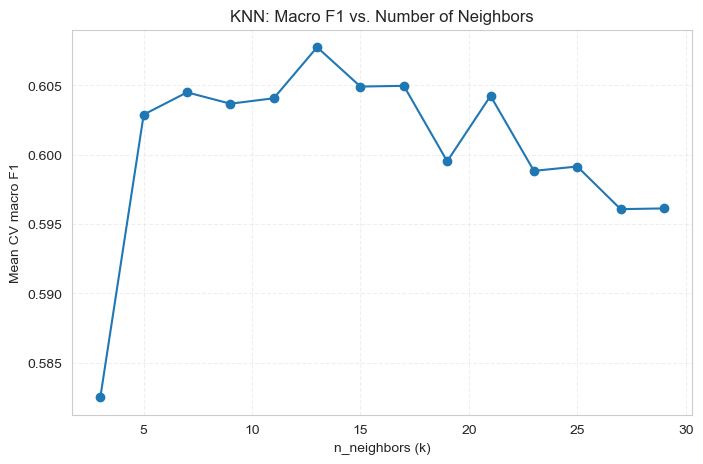

In [89]:
# Extract results for macro F1
results = grid_search.cv_results_

# Create a dataframe for easier analysis
cv_results_df = pd.DataFrame(results)

# Group by n_neighbors and take mean test score
mean_scores = (
    cv_results_df
    .groupby("param_knn__n_neighbors")["mean_test_score"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(mean_scores.index.astype(int), mean_scores.values, marker="o")
plt.xlabel("n_neighbors (k)")
plt.ylabel("Mean CV macro F1")
plt.title("KNN: Macro F1 vs. Number of Neighbors")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

1.	Tuning did not improve test performance here  
GridSearchCV chose the hyperparameters that gave the best average cross‑validated score on the training data, not necessarily the best on your single test set.

2.	Class-wise changes
•	Dropout:
•	Precision improved (0.73 → 0.78)
•	Recall dropped (0.65 → 0.61)  
→ The model is more “conservative” in predicting Dropout: when it does, it’s more often right, but it misses more actual Dropouts.
•	Enrolled:
•	Precision similar (0.39 → 0.39)
•	Recall worse (0.30 → 0.24)  
→ Still the weakest class; tuning didn’t help here.
•	Graduate:
•	Precision slightly worse (0.74 → 0.72)
•	Recall better (0.85 → 0.91)  
→ The model leans more toward predicting Graduate, which helps recall but slightly hurts precision.
Confusion matrix shows this clearly:
•	More actual Dropouts are predicted as Graduate (64 → 75).
•	More actual Enrolled are predicted as Graduate (69 → 86).
•	More Graduates are correctly predicted (376 → 404).

Opting to tune a slighlty different - Narrow the grid around the best  n_neighbors  found.

In [90]:
grid_search.best_params_

{'knn__n_neighbors': 13, 'knn__weights': 'distance'}

In [91]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = make_scorer(f1_score, average="macro")

# Example: suppose best n_neighbors was 11
# Adjust these numbers based on your actual best_params_
best_n = grid_search.best_params_["knn__n_neighbors"]

n_neighbors_range = list(range(max(3, best_n - 4), best_n + 5, 1))

param_grid_narrow = {
    "knn__n_neighbors": n_neighbors_range,
    "knn__weights": ["uniform", "distance"]
    # optionally add:
    # "knn__metric": ["minkowski", "euclidean", "manhattan"]
}

grid_search_narrow = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_narrow,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1
)

grid_search_narrow.fit(X_train, y_train)

print("Best parameters (narrow grid):", grid_search_narrow.best_params_)
print("Best CV macro F1 (narrow grid):", grid_search_narrow.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters (narrow grid): {'knn__n_neighbors': 16, 'knn__weights': 'distance'}
Best CV macro F1 (narrow grid): 0.6111740195174626


In [92]:
best_model_narrow = grid_search_narrow.best_estimator_
y_pred_narrow = best_model_narrow.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_narrow))
print("\nClassification report:")
print(classification_report(y_test, y_pred_narrow))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_narrow))

Balanced accuracy: 0.5768222032232287

Classification report:
              precision    recall  f1-score   support

     Dropout       0.77      0.61      0.68       284
    Enrolled       0.38      0.19      0.26       159
    Graduate       0.71      0.93      0.81       442

    accuracy                           0.69       885
   macro avg       0.62      0.58      0.58       885
weighted avg       0.67      0.69      0.67       885


Confusion matrix:
[[172  32  80]
 [ 40  31  88]
 [ 12  19 411]]


RandomizedSearchCV

In [93]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = make_scorer(f1_score, average="macro")

param_dist = {
    "knn__n_neighbors": randint(3, 31),       # random int in [3, 30]
    "knn__weights": ["uniform", "distance"]
}

random_search = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=param_dist,
    n_iter=25,                # number of random combinations to try
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters (random search):", random_search.best_params_)
print("Best CV macro F1 (random search):", random_search.best_score_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters (random search): {'knn__n_neighbors': 13, 'knn__weights': 'distance'}
Best CV macro F1 (random search): 0.6109155862672577


In [94]:
best_model_random = random_search.best_estimator_
y_pred_random = best_model_random.predict(X_test)

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_random))
print("\nClassification report:")
print(classification_report(y_test, y_pred_random))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_random))


Balanced accuracy: 0.5873919298635185

Classification report:
              precision    recall  f1-score   support

     Dropout       0.78      0.61      0.68       284
    Enrolled       0.39      0.24      0.30       159
    Graduate       0.72      0.91      0.80       442

    accuracy                           0.69       885
   macro avg       0.63      0.59      0.59       885
weighted avg       0.68      0.69      0.67       885


Confusion matrix:
[[173  36  75]
 [ 35  38  86]
 [ 14  24 404]]


## Imbalance

### Target-Class Balance Check

Before applying any balancing technique, we:

1. Identify the target column.
2. Count the number of examples in each class.
3. Calculate class percentages.
4. Decide whether the dataset has a significant imbalance.
5. Visualize the class distribution.


In [95]:
# Target
target_col = "Target"

# Class counts
class_counts = df_student[target_col].value_counts()

# Class percentages
class_perc = df_student[target_col].value_counts(normalize=True).mul(100).round(2)

print("Class counts:\n", class_counts)
print("\nClass percentages (%):\n", class_perc)

Class counts:
 Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Class percentages (%):
 Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_72420/1312522367.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


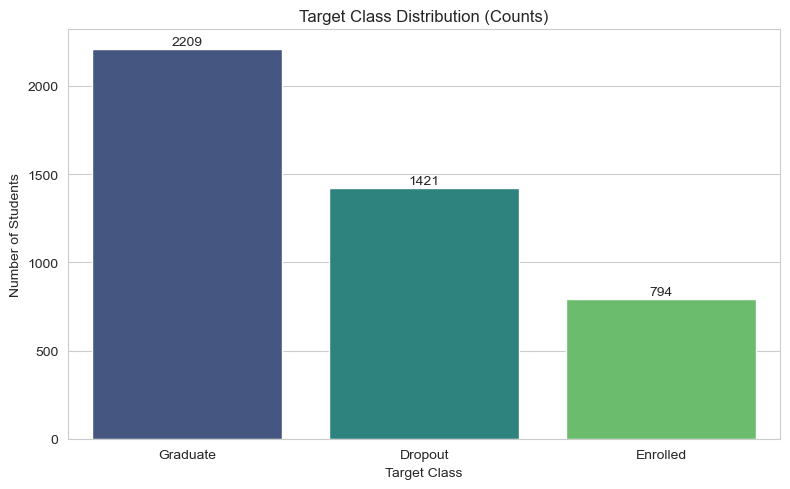

In [96]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette="viridis"
)

plt.title("Target Class Distribution (Counts)")
plt.xlabel("Target Class")
plt.ylabel("Number of Students")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()


/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_72420/3184982830.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


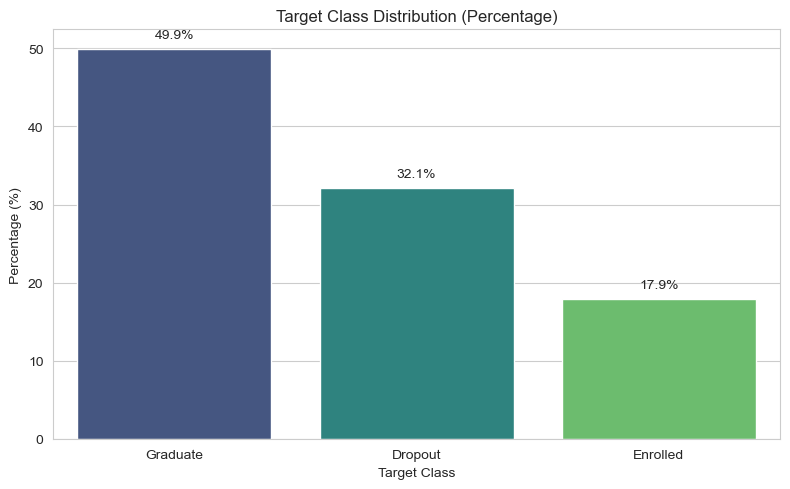

In [97]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_perc.index,
    y=class_perc.values,
    palette="viridis"
)

plt.title("Target Class Distribution (Percentage)")
plt.xlabel("Target Class")
plt.ylabel("Percentage (%)")

for i, v in enumerate(class_perc.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


The target variable has three classes: Dropout, Enrolled, and Graduate.  

The Enrolled class represents approximately 18% of the data, while Dropout and Graduate represent around 32% and 50%, respectively.  

Because one class is clearly underrepresented, the dataset is considered moderately imbalanced. 

This can cause models to be biased toward the majority class (Graduate) and perform poorly on the minority classes, especially Enrolled.

## Balancing Techniques for Imbalanced Data

To reduce bias toward the majority class, we will:

1. Split the data into training and test sets (stratified by target).
2. Apply a balancing technique only to the training data.
3. Retrain the model using the balanced training set.
4. Compare performance before and after balancing using the same test set.

We will focus on:
- SMOTE (synthetic oversampling) for the training data.
- Optionally, class weights in models that support them.


Train–test split (stratified)

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keep class proportions in train and test
)

print("Original training class distribution:")
print(y_train.value_counts())
print("\nOriginal test class distribution:")
print(y_test.value_counts())


Original training class distribution:
Target
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Original test class distribution:
Target
Graduate    442
Dropout     284
Enrolled    159
Name: count, dtype: int64


- SMOTE is applied **only to the training set**.
- The test set remains unchanged to reflect the real class distribution.

In [99]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training data
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Class distribution BEFORE SMOTE (train):")
print(Counter(y_train))

print("\nClass distribution AFTER SMOTE (train):")
print(Counter(y_train_sm))

Class distribution BEFORE SMOTE (train):
Counter({'Graduate': 1767, 'Dropout': 1137, 'Enrolled': 635})

Class distribution AFTER SMOTE (train):
Counter({'Graduate': 1767, 'Dropout': 1767, 'Enrolled': 1767})


/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_72420/863363402.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_72420/863363402.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


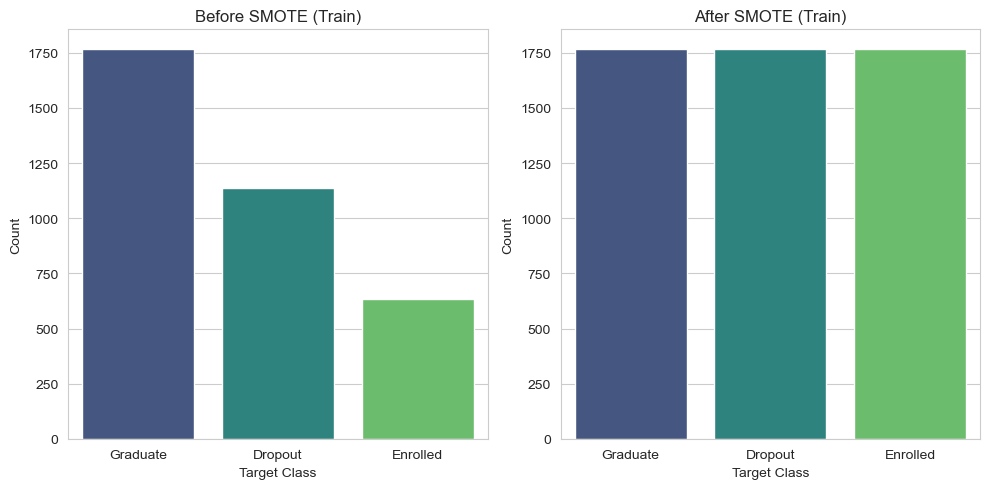

In [100]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(
    x=pd.Series(Counter(y_train)).index,
    y=pd.Series(Counter(y_train)).values,
    palette="viridis"
)
plt.title("Before SMOTE (Train)")
plt.xlabel("Target Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.barplot(
    x=pd.Series(Counter(y_train_sm)).index,
    y=pd.Series(Counter(y_train_sm)).values,
    palette="viridis"
)
plt.title("After SMOTE (Train)")
plt.xlabel("Target Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


Retrainning KNN model with SMOTE-balanced training data

In [101]:
# Baseline model (original imbalanced train)
knn_base = KNeighborsClassifier()
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)

# SMOTE-balanced model
knn_smote = KNeighborsClassifier()
knn_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = knn_smote.predict(X_test)


In [102]:
print("=== Baseline KNN (imbalanced train) ===")
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_base))
print("\nClassification report:")
print(classification_report(y_test, y_pred_base))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_base))

print("\n=== KNN with SMOTE (balanced train) ===")
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_smote))
print("\nClassification report:")
print(classification_report(y_test, y_pred_smote))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_smote))

=== Baseline KNN (imbalanced train) ===
Balanced accuracy: 0.523529892751884

Classification report:
              precision    recall  f1-score   support

     Dropout       0.62      0.59      0.60       284
    Enrolled       0.27      0.21      0.23       159
    Graduate       0.70      0.77      0.73       442

    accuracy                           0.61       885
   macro avg       0.53      0.52      0.52       885
weighted avg       0.59      0.61      0.60       885


Confusion matrix:
[[168  36  80]
 [ 57  33  69]
 [ 48  53 341]]

=== KNN with SMOTE (balanced train) ===
Balanced accuracy: 0.5087416413446958

Classification report:
              precision    recall  f1-score   support

     Dropout       0.58      0.54      0.56       284
    Enrolled       0.23      0.42      0.30       159
    Graduate       0.74      0.57      0.65       442

    accuracy                           0.53       885
   macro avg       0.52      0.51      0.50       885
weighted avg       0.60 

Using a Pipeline with SMOTE + KNN (cleaner for CV later)

In [103]:
from imblearn.pipeline import Pipeline as ImbPipeline

knn_smote_pipeline = ImbPipeline(
    steps=[
        ("smote", SMOTE(random_state=42)),
        ("knn", KNeighborsClassifier())
    ]
)

knn_smote_pipeline.fit(X_train, y_train)
y_pred_smote_pipe = knn_smote_pipeline.predict(X_test)

print("Balanced accuracy (pipeline):", balanced_accuracy_score(y_test, y_pred_smote_pipe))
print("\nClassification report:")
print(classification_report(y_test, y_pred_smote_pipe))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_smote_pipe))


Balanced accuracy (pipeline): 0.5087416413446958

Classification report:
              precision    recall  f1-score   support

     Dropout       0.58      0.54      0.56       284
    Enrolled       0.23      0.42      0.30       159
    Graduate       0.74      0.57      0.65       442

    accuracy                           0.53       885
   macro avg       0.52      0.51      0.50       885
weighted avg       0.60      0.53      0.56       885


Confusion matrix:
[[153  85  46]
 [ 50  66  43]
 [ 59 130 253]]


## Effect of SMOTE on KNN Performance

Applying SMOTE to balance the training data resulted in lower performance on the held-out test set compared to the baseline KNN model trained on the original imbalanced data.

Key observations:

- Balanced accuracy decreased from approximately 0.60 (baseline KNN) to 0.51 (SMOTE + KNN).
- Macro F1-score decreased from around 0.59–0.61 to about 0.50.
- Recall for the Graduate class dropped substantially, while precision for the Enrolled class remained very low.
- The confusion matrix shows increased confusion between all three classes, especially involving the Enrolled class.

These results suggest that, for this dataset and feature representation, SMOTE introduced noise and/or distorted the local neighborhood structure that KNN relies on. Possible reasons include:

- The presence of mixed categorical and numerical features, where standard SMOTE may create unrealistic synthetic samples.
- Overlapping class boundaries and noisy minority-class regions, which SMOTE can amplify.
- A mismatch between the perfectly balanced training distribution and the real-world imbalanced test distribution.

Therefore, in this project, SMOTE oversampling did not improve the generalization of the KNN classifier and is not recommended in its current configuration. Alternative strategies, such as using models with built-in class weighting, different resampling methods, or feature engineering, should be explored as next steps.


The End.